# **Definición del problema**



En una empresa de seguros, uno de los principales desafíos es calcular el monto adecuado que se debe cobrar por una póliza de vida, de manera que se asegure un margen de ganancia. Este valor, conocido como prima, también tiene un impacto directo en las reservas que debe mantener la institución para cubrir futuros pagos de indemnizaciones.

Estas reservas representan los montos que la aseguradora adeuda a sus asegurados por reclamos que podrían presentarse en el futuro. Por tanto, constituyen un pasivo, ya que implican una estimación del dinero que la empresa deberá pagar como indemnización. Un cálculo incorrecto puede llevar a un déficit financiero o, por el contrario, a una acumulación innecesaria de fondos sin utilizar.

Además de la estabilidad financiera, el cálculo preciso de la prima también es clave para mantener la competitividad en el mercado. Por eso, se plantea como objetivo el desarrollo de un modelo predictivo que permita estimar cuánto se debe cobrar por una póliza de vida.

Para este fin, se dispone de un conjunto de datos de aproximadamente 1300 registros provenientes de una empresa de la competencia. Este dataset incluye variables como: edad, sexo, índice de masa corporal (BMI), número de hijos, condición de fumador, región y el costo de la póliza. Con base en esta información, se espera construir un modelo que permita optimizar el cálculo de primas y mejorar la posición competitiva de la empresa.

Para medir la precisión del modelo, se utilizará R2, ya que se considera para este proyecto como el más adecuado, y se buscará una medición mínima de 0.70.

# **Observación general de las variables**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from matplotlib import style
import matplotlib.ticker as ticker

In [6]:
datos = pd.read_csv('/content/insurance.csv')

datos.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [7]:
# Tipo de Datos que contiene cada columna

datos.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [8]:
# Cantidad de filas y columnas

datos.shape

(1338, 7)

In [9]:
#Numero de Valores Faltantes o Vacios

datos.isnull().sum().sort_values(ascending=False)

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


<Axes: ylabel='charges'>

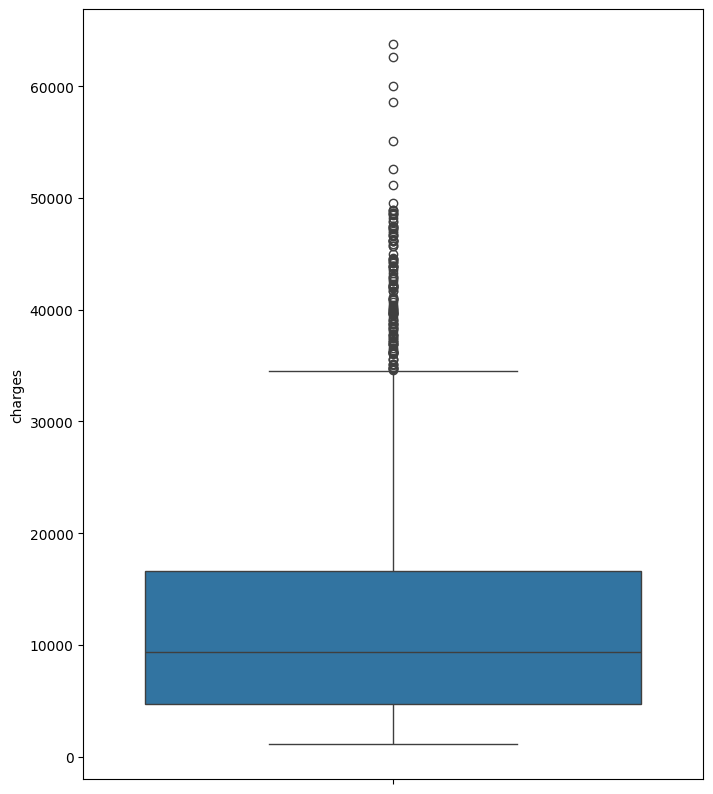

In [10]:
#Revisar outliers

plt.figure(figsize = (8, 10))
sns.boxplot(y = datos['charges'])

In [11]:
#Técnica Rango intercuartílico

## Obtener el valor atipico ##

def fuera_rango_iqr (Dataset,columna):
  """ Esta funcion me extrae los valores atipicos del metodo del boxplot """
  global inferior, superior
  Q1, Q3 = np.quantile(Dataset[columna], 0.25), np.quantile(Dataset[columna], 0.75)
  ## Calcular el Rango Intercuartilico ##
  IQR = Q3 - Q1
  # Calcular los cortes atipicos #
  corte_atipico = IQR * 1.5
  inferior, superior = Q1 - corte_atipico, Q3 + corte_atipico
  print('El IQR es: ', IQR)
  print('El limite Inferior es: ', inferior)
  print('El limite Superior es: ', superior)
  #Calcular la cantidad de observaciones en los limites superior e inferiores
  df1 = Dataset[Dataset[columna]>superior]
  df2 = Dataset[Dataset[columna]<inferior]
  return print('Cantidad de valores atipicos es: ', df1.shape[0] + df2.shape[0])



In [12]:
fuera_rango_iqr(datos,'charges')

El IQR es:  11899.625365
El limite Inferior es:  -13109.1508975
El limite Superior es:  34489.350562499996
Cantidad de valores atipicos es:  139


In [13]:
# Aplicar los límites inferior y superior a la columna 'charges'

# Se eliminan los valores atípicos

datos = datos[np.logical_and( datos['charges']>inferior,  datos['charges']<superior)]


<Axes: ylabel='charges'>

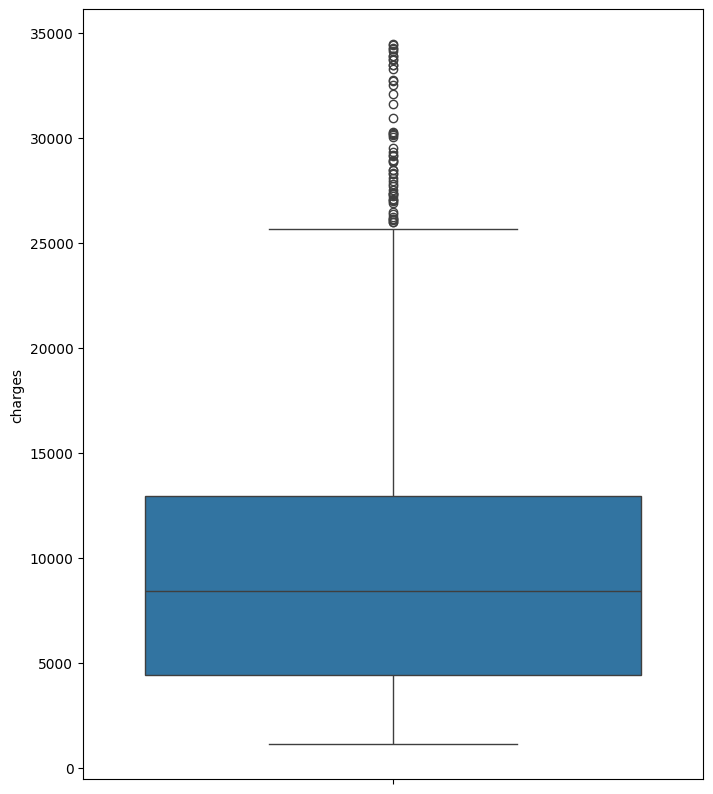

In [14]:
plt.figure(figsize = (8, 10))
sns.boxplot(y = datos['charges'])

In [15]:
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

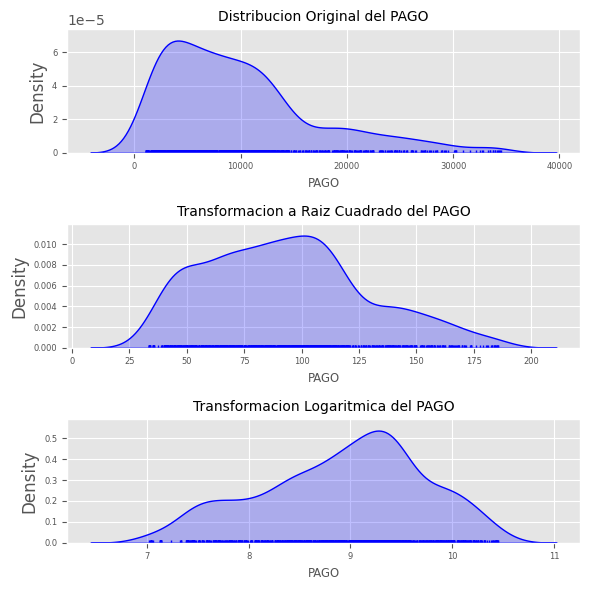

In [16]:
#Revisar la distribución de la columna charges

fig, axes = plt.subplots(nrows = 3, ncols= 1,figsize=(6, 6))

sns.distplot(
    datos['charges'],
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[0])

axes[0].set_title('Distribucion Original del PAGO', fontsize = 'medium')
axes[0].set_xlabel('PAGO', fontsize = 'small')
axes[0].tick_params(labelsize = 6)

###############################################################################

sns.distplot(
    np.sqrt(datos['charges']), ##
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[1])

axes[1].set_title('Transformacion a Raiz Cuadrado del PAGO', fontsize = 'medium') ##
axes[1].set_xlabel('PAGO', fontsize = 'small')
axes[1].tick_params(labelsize = 6)

###############################################################################

sns.distplot(
    np.log(datos['charges']), ##
    hist = False,
    rug = True,
    color= 'blue',
    kde_kws= {'shade': True, 'linewidth':1},
    ax = axes[2])

axes[2].set_title('Transformacion Logaritmica del PAGO', fontsize = 'medium') ##
axes[2].set_xlabel('PAGO', fontsize = 'small')
axes[2].tick_params(labelsize = 6)


fig.tight_layout()
plt.show()

In [17]:
#Se utiliza la versión logaritmica que tiene una distribución más cercana a la normal

datos['charges'] = np.log(datos['charges'])

In [18]:
# Estadistica Descriptiva de las variables numericas

datos.select_dtypes(include=np.number).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,1199.0,38.99,14.07,18.00,26.00,39.00,51.00,64.00
bmi,1199.0,30.10,6.01,15.96,25.80,29.74,33.82,53.13
children,1199.0,1.08,1.21,0.00,0.00,1.00,2.00,5.00
charges,1199.0,8.92,0.80,7.02,8.39,9.04,9.47,10.45


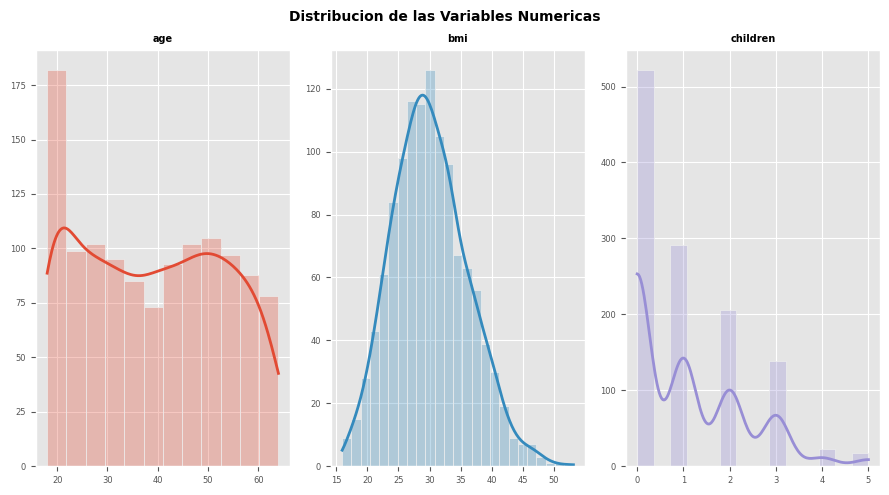

In [19]:
#Grafica de Distribucion para cada variable numerica

fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(9,5))
axes=axes.flat
columnas_numericas=datos.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('charges')

for i,columna in enumerate(columnas_numericas):
  sns.histplot(
    data=datos,
    x=columna,
    stat='count',
    kde= True,
    color=list(plt.rcParams['axes.prop_cycle']*2)[i]['color'],
    line_kws={'linewidth':2},
    alpha=0.3,
    ax=axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')


fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribucion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

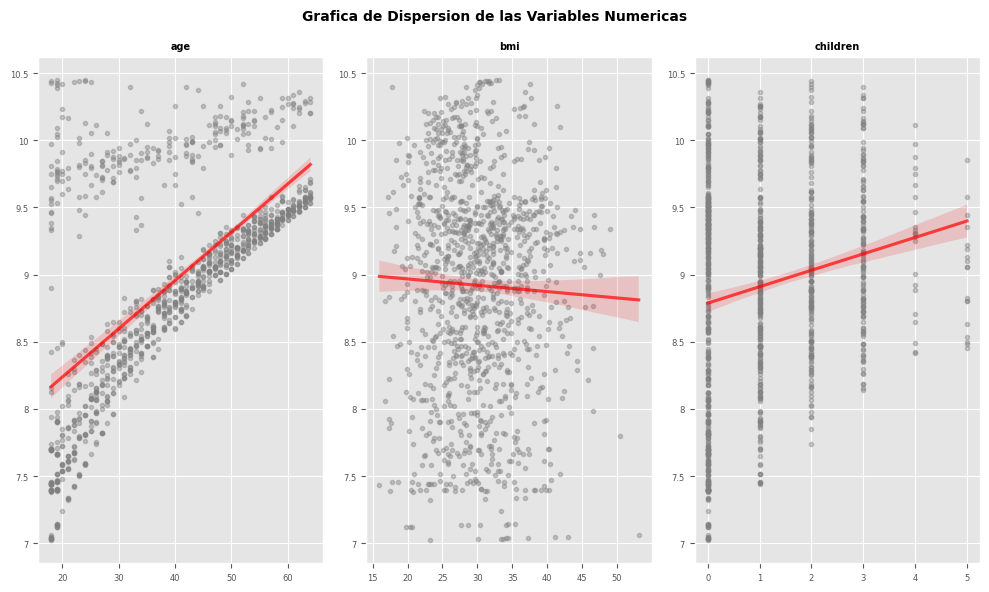

In [20]:
#Grafica de Dispersion para cada variable numerica y su relacion con la variable dependiente

fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(10,6))
axes=axes.flat
columnas_numericas=datos.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('charges')

for i,columna in enumerate(columnas_numericas):
  sns.regplot(
    data=datos,
    x=datos[columna],
    y='charges',
    color = 'gray',
    marker = '.',
    scatter_kws= {'alpha': 0.4},
    line_kws = {'color':'red', 'alpha':0.7},
    ax = axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')



fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Grafica de Dispersion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

## Correlacion Variables Numericas

In [21]:
# Correlacion entre Variables Numericas

def matriz_correlacion(corr_mat):
  """ Funcion para convertir una matrix de correlacion a un formato tipo DataFrame """
  corr_mat=corr_mat.stack().reset_index()
  corr_mat.columns=['variable_1','variable_2','correlacion']
  corr_mat= corr_mat.loc[corr_mat['variable_1']!=corr_mat['variable_2'],:]
  corr_mat['Absoluto']=np.abs(corr_mat['correlacion'])
  corr_mat=corr_mat.sort_values('Absoluto',ascending=False)
  return corr_mat


corr_matrix = datos.select_dtypes(include = np.number).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(10)

,variable_1,variable_2,correlacion,Absoluto
3,age,charges,0.634865,0.634865
12,charges,age,0.634865,0.634865
11,children,charges,0.186403,0.186403
14,charges,children,0.186403,0.186403
1,age,bmi,0.119505,0.119505
4,bmi,age,0.119505,0.119505
2,age,children,0.040215,0.040215
8,children,age,0.040215,0.040215
7,bmi,charges,-0.035514,0.035514
13,charges,bmi,-0.035514,0.035514


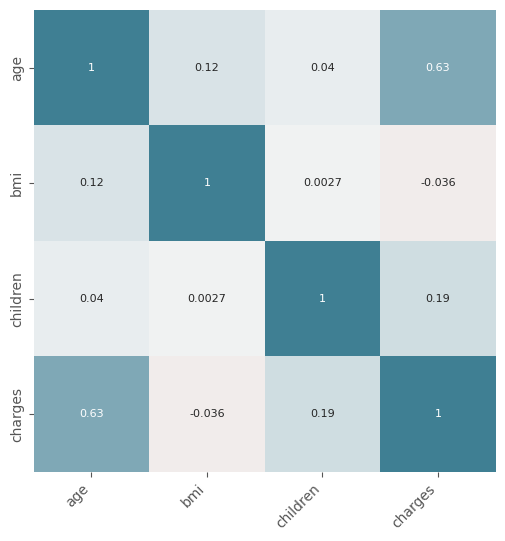

In [22]:
##HeatMap de Correlaciones

fig, axes = plt.subplots(nrows = 1, ncols =1, figsize = (6,6))

sns.heatmap(
    corr_matrix,
    cmap = sns.diverging_palette(20,220, n = 200),
    square = True,
    annot = True,
    center = 0,
    vmin = -1,
    vmax = 1,
    annot_kws = {'fontsize':8},
    cbar = False,
    ax = axes)

axes.set_xticklabels(axes.get_xticklabels(), rotation = 45, horizontalalignment = 'right')

plt.show()

Se observa una relación en las columnas de la edad con el costo de la prima

## Variables Cualitativas

In [23]:
#Seleccionar las variables cualitativas

datos.select_dtypes(include = 'object')

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


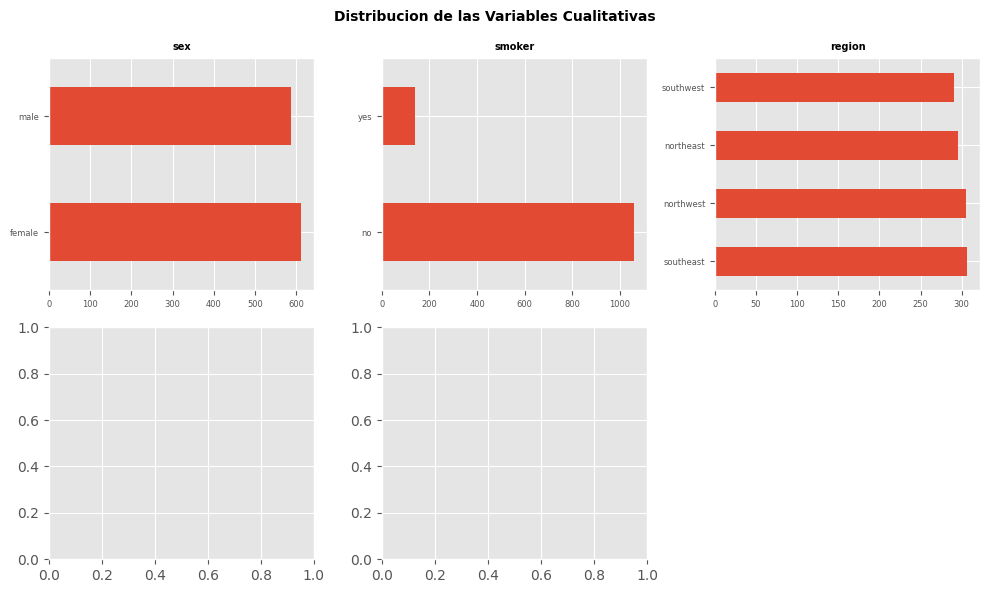

In [24]:
#Grafico para cada variable cualitativa

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,6))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include = 'object').columns

for i, columna in enumerate(columnas_cualitativas):
  datos[columna].value_counts().plot(
      kind = 'barh',
      ax = axes[i])
  axes[i].set_title(columna, fontsize = 7, fontweight = 'bold')
  axes[i].tick_params(labelsize = 6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

for i in [5]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Distribucion de las Variables Cualitativas', fontsize = 'medium', fontweight = 'bold')
plt.show()

Text(0.5, 0.98, 'Grafica de Precio vs Variables Cualitativas')

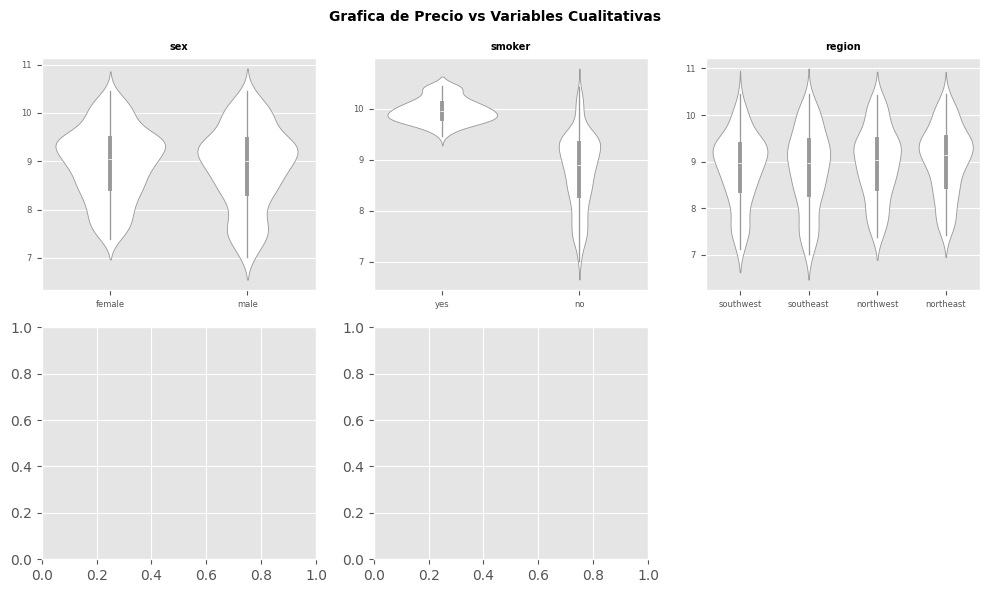

In [26]:
##Grafico relacion entre el precio y las variables cualitativas

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,6))
axes = axes.flat
columnas_cualitativas = datos.select_dtypes(include = 'object').columns

for i, columna in enumerate(columnas_cualitativas):
  sns.violinplot(
      data = datos,
      x = columna,
      y = 'charges',
      color = 'white',
      ax = axes[i])

  axes[i].set_title(columna, fontsize = 7, fontweight = 'bold')
  axes[i].tick_params(labelsize = 6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')
  axes[i].yaxis.set_major_formatter(ticker.EngFormatter())

for i in [5]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Grafica de Precio vs Variables Cualitativas', fontsize = 'medium', fontweight = 'bold')

# Division Train - Test

In [29]:
from re import X
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos.drop('charges', axis = 'columns'),
    datos.charges,
    train_size = 0.8,
    test_size = 0.2,
    random_state = 42,
    shuffle = True)

In [30]:
print('Resultado de la Particion de los Datos de Entrenamiento',
      '-------------------------------------------------------',
      y_train.describe().round(2),
      '-------------------------------------------------------',
      sep = '\n')

Resultado de la Particion de los Datos de Entrenamiento
-------------------------------------------------------
count    959.00
mean       8.91
std        0.78
min        7.02
25%        8.40
50%        9.03
75%        9.44
max       10.45
Name: charges, dtype: float64
-------------------------------------------------------


In [31]:
print('Resultado de la Particion de los Datos de Prueba',
      '-------------------------------------------------------',
      y_test.describe().round(2),
      '-------------------------------------------------------',
      sep = '\n')

Resultado de la Particion de los Datos de Prueba
-------------------------------------------------------
count    240.00
mean       8.96
std        0.85
min        7.04
25%        8.37
50%        9.07
75%        9.58
max       10.44
Name: charges, dtype: float64
-------------------------------------------------------


Preprocesamiento de Datos

In [35]:
#Pipeline / Tuberia de Transformaciones y Preprocesamiento

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Escalar los datos

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()

preprocesamiento = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), columnas_numericas),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_cualitativas)])

In [36]:
X_train_preprocesado = preprocesamiento.fit_transform(X_train)
X_test_preprocesado = preprocesamiento.transform(X_test)

In [37]:
variables_codificadas = preprocesamiento.named_transformers_['onehot'].get_feature_names_out(columnas_cualitativas)
etiquetas = np.concatenate([columnas_numericas, variables_codificadas])
datos_train_preprocesados = pd.DataFrame(X_train_preprocesado, columns = etiquetas)
datos_test_preprocesados = pd.DataFrame(X_test_preprocesado, columns = etiquetas)

datos_train_preprocesados.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-0.004862,-0.850680,1.569536,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.712524,1.072862,1.569536,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.296158,1.541459,-0.896633,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.296158,-0.710593,0.747480,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.640786,-0.927688,-0.896633,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [38]:
datos_train_preprocesados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               959 non-null    float64
 1   bmi               959 non-null    float64
 2   children          959 non-null    float64
 3   sex_female        959 non-null    float64
 4   sex_male          959 non-null    float64
 5   smoker_no         959 non-null    float64
 6   smoker_yes        959 non-null    float64
 7   region_northeast  959 non-null    float64
 8   region_northwest  959 non-null    float64
 9   region_southeast  959 non-null    float64
 10  region_southwest  959 non-null    float64
dtypes: float64(11)
memory usage: 82.5 KB


In [39]:
from sklearn.impute import SimpleImputer

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()

transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])


transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])


preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

In [40]:
X_train_preprocesado = preprocesamiento.fit_transform(X_train)
X_test_preprocesado = preprocesamiento.transform(X_test)

In [41]:
variables_codificadas = preprocesamiento.named_transformers_['cualitativas']['onehot'].get_feature_names_out(columnas_cualitativas)
etiquetas = np.concatenate([columnas_numericas, variables_codificadas])
datos_train_preprocesados = pd.DataFrame(X_train_preprocesado, columns = etiquetas)
datos_test_preprocesados = pd.DataFrame(X_test_preprocesado, columns = etiquetas)

datos_train_preprocesados.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-0.004862,-0.850680,1.569536,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.712524,1.072862,1.569536,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.296158,1.541459,-0.896633,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.296158,-0.710593,0.747480,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.640786,-0.927688,-0.896633,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Modelo de Datos

## Entrenamiento

In [43]:
from sklearn.linear_model import Ridge

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])

#Asignar los resultados _ para que no se imprima la ejecucion en el notebook

_ = pipe.fit(X_train, y_train)

In [44]:
# Validacion Cruzada

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = 5,
    scoring = 'r2'
)


print(f'Metricas de Validacion Cruzada: {cv_scores}')
print(f'Promedio de Metricas: {cv_scores.mean()}', sep = '\n')

Metricas de Validacion Cruzada: [0.64062227 0.66957297 0.76030247 0.75255823 0.75681678]
Promedio de Metricas: 0.7159745450844308


In [45]:
#Validacion Cruzada Repetita

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'r2'
)


print(f'Metricas de Validacion Cruzada: {cv_scores}')
print(f'Promedio de Metricas: {cv_scores.mean()}', sep = '\n')

Metricas de Validacion Cruzada: [0.63046086 0.60798115 0.76108716 0.78594072 0.76388119 0.58705174
 0.76543691 0.72984005 0.76447595 0.70052797 0.71786243 0.78240634
 0.61545229 0.72052453 0.74423243]
Promedio de Metricas: 0.71181078101877


In [46]:
#Validacion Cruzada con multiples metricas
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 42)

cv_scores = cross_validate(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = ('r2', 'neg_root_mean_squared_error'),
    return_train_score = True
)

#Pasemos los resultados a un dataframe

cv_scores = pd.DataFrame(cv_scores)
cv_scores

,fit_time,score_time,test_r2,train_r2,test_neg_root_mean_squared_error,train_neg_root_mean_squared_error
0,0.013322,0.008832,0.630461,0.743669,-0.459206,-0.399075
1,0.012707,0.008561,0.607981,0.747722,-0.462642,-0.397579
2,0.012319,0.008539,0.761087,0.714058,-0.371979,-0.420735
3,0.014059,0.009120,0.785941,0.703664,-0.390309,-0.416717
4,0.012795,0.008653,0.763881,0.711780,-0.389941,-0.416754
5,0.013079,0.008463,0.587052,0.747881,-0.463588,-0.397632
6,0.012863,0.008731,0.765437,0.710882,-0.390279,-0.416406
7,0.013585,0.008590,0.729840,0.720319,-0.424959,-0.408342
8,0.013016,0.008294,0.764476,0.712354,-0.384421,-0.417840
9,0.017690,0.013758,0.700528,0.728608,-0.409470,-0.411492


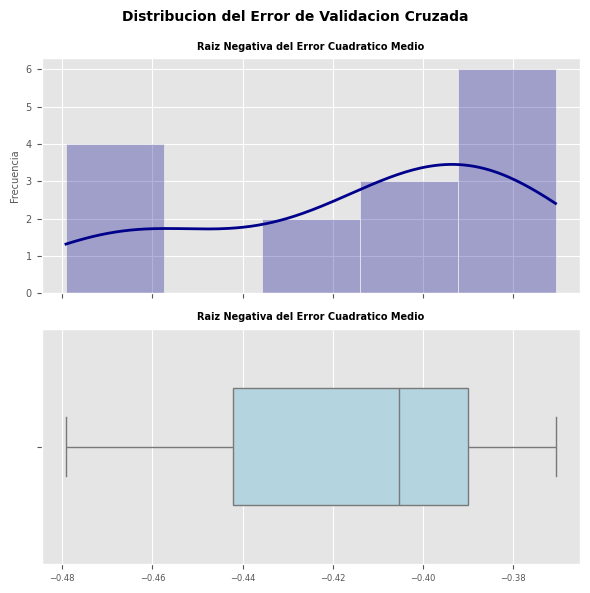

In [47]:
#Distribucion del error de la validacion cruzada

fig, axes = plt.subplots(2, 1, figsize = (6, 6), sharex=True)

sns.histplot(
    data = cv_scores,
    x = 'test_neg_root_mean_squared_error',
    stat = 'count',
    kde = True,
    line_kws = {'linewidth': 2},
    color = 'darkblue',
    alpha = 0.3,
    ax = axes[0]
)

axes[0].set_title('Raiz Negativa del Error Cuadratico Medio', fontsize = 7, fontweight = 'bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frecuencia', fontsize = 7)
axes[0].tick_params(axis = 'both', labelsize = 7)

sns.boxplot(
    data = cv_scores,
    x = 'test_neg_root_mean_squared_error',
    color = 'lightblue',
    width = 0.5,
    ax = axes[1]
)

axes[1].set_title('Raiz Negativa del Error Cuadratico Medio', fontsize = 7, fontweight = 'bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis = 'both', labelsize = 6)

fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Distribucion del Error de Validacion Cruzada', fontsize = 10, fontweight = 'bold')
plt.show()

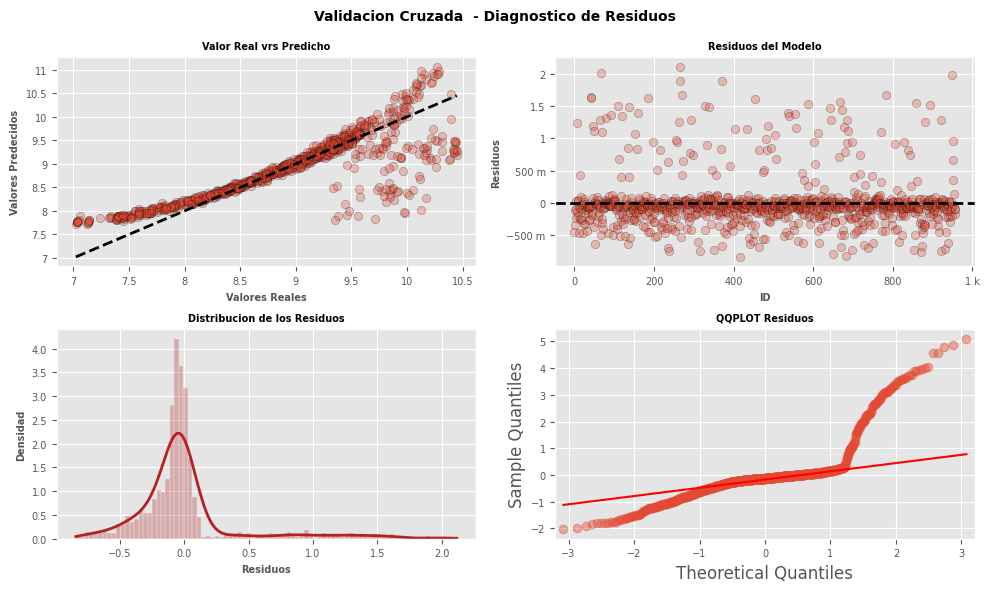

In [48]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold
import statsmodels.api as sm

#Validacion Cruzada

cv = KFold(n_splits = 5, shuffle = True, random_state = 123)

cv_predicciones = cross_val_predict(
    estimator = pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    n_jobs = -1
)

#Graficos Dispersion Real Vrs Predicho

fig, axes = plt.subplots(2, 2, figsize = (10, 6))

axes[0,0].scatter(
    x = y_train,
    y = cv_predicciones,
    alpha = 0.3,
    edgecolors = (0,0,0))

axes[0,0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    color = 'black',
    linewidth = 2,
    linestyle = '--')

axes[0,0].set_xlabel('Valores Reales', fontsize = 7, fontweight = 'bold')
axes[0,0].set_ylabel('Valores Predecidos', fontsize = 7, fontweight = 'bold')
axes[0,0].tick_params(axis = 'both', labelsize = 7)
axes[0,0].set_title('Valor Real vrs Predicho', fontsize = 7, fontweight = 'bold')
axes[0,0].yaxis.set_major_formatter(ticker.EngFormatter())
axes[0,0].xaxis.set_major_formatter(ticker.EngFormatter())


#Graficos Dispersion de Residuos
axes[0,1].scatter(
    x = np.arange(len(y_train)),
    y = y_train - cv_predicciones,
    alpha = 0.3,
    edgecolors = (0,0,0))

axes[0,1].axhline(
    y = 0,
    color = 'black',
    linewidth = 2,
    linestyle = '--')

axes[0,1].set_title('Residuos del Modelo', fontsize = 7, fontweight = 'bold')
axes[0,1].set_xlabel('ID', fontsize = 7, fontweight = 'bold')
axes[0,1].set_ylabel('Residuos', fontsize = 7, fontweight = 'bold')
axes[0,1].tick_params(axis = 'both', labelsize = 7)
axes[0,1].yaxis.set_major_formatter(ticker.EngFormatter())
axes[0,1].xaxis.set_major_formatter(ticker.EngFormatter())

#Distribucion de los Residuos
sns.histplot(
    data = y_train - cv_predicciones,
    stat = 'density',
    kde = True,
    line_kws = {'linewidth': 2},
    color = 'firebrick',
    alpha = 0.3,
    ax = axes[1,0]
)

axes[1,0].set_title('Distribucion de los Residuos', fontsize = 7, fontweight = 'bold')
axes[1,0].set_xlabel('Residuos', fontsize = 7, fontweight = 'bold')
axes[1,0].set_ylabel('Densidad', fontsize = 7, fontweight = 'bold')
axes[1,0].tick_params(axis = 'both', labelsize = 7)

##Grafico QQPLOT
sm.qqplot(
    y_train - cv_predicciones,
    fit = True,
    line = 'q',
    color = 'firebrick',
    alpha = 0.4,
    lw = 2,
    ax = axes[1,1]
)

axes[1,1].set_title('QQPLOT Residuos', fontsize = 7, fontweight = 'bold')
axes[1,1].tick_params(labelsize = 7)

#########
fig.tight_layout()
plt.subplots_adjust(top = 0.9)
plt.suptitle('Validacion Cruzada  - Diagnostico de Residuos', fontsize = 10, fontweight = 'bold')
plt.show()

Lo que se puede observar en la gráfica 1, es que los casos con primas más altas, son más complejos de calcular por el modelo.

In [49]:
from sklearn.model_selection import RepeatedKFold

cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

cv_scores = cross_val_score(
    estimator=pipe,
    X = X_train,
    y = y_train,
    cv = cv,
    scoring = 'r2',
    n_jobs = -1 #todos los core disponible
)

print(f'Promedio de Metricas: {cv_scores.mean()}')

Promedio de Metricas: 0.7128747797409101


# Predicciones

In [50]:
predicciones = pipe.predict(X_test)

In [51]:
# Se crea un DataFrame con las predicciones y el valor real

df_predicciones = pd.DataFrame(
    data = {'Valor Real': y_test, 'Predicciones': predicciones}
)

df_predicciones.head(10).round(2)

,Valor Real,Predicciones
1315,9.33,7.99
965,8.47,8.46
117,9.86,9.70
492,7.69,7.97
69,9.78,9.76
1210,8.59,8.63
367,8.99,9.04
1085,9.85,10.45
462,9.63,9.91
1333,9.27,9.38


## Error del TEST

In [ ]:
## MAE

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predicciones)

print(mae)

0.28849951080990327


In [52]:
## MSE

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true= y_test, y_pred= predicciones)

print(mse)

0.24407108967556304


In [53]:
## RMSE

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true= y_test, y_pred= predicciones)

print(np.sqrt(mse))

0.4940355145893492


In [54]:
## R2
from sklearn.metrics import r2_score

r2 = r2_score(
    y_true=  y_test,
    y_pred= predicciones)

print(r2)

0.6619109192916297


In [55]:
## R2 Ajustado

n = len(y_test) #Cantidad de Observaciones del test
k = X_test.shape[1] #Cantidad de Variables Independientes

r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(r2_ajustado)

0.6532047627068648


# Hiperparámetros

In [56]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', Ridge())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'modelo__alpha':np.logspace(-5,3,10)} #10^-5 hasta 10^3
\

grid = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0
)

grid

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=123),
             estimator=Pipeline(steps=[('preprocesamiento',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('numericas',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cualitativas',
                                                                         Pipeline(steps=[('imputer',
                                                                                          Simp...
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('modelo', Ridge())]),
             n_jobs=1,
             param_grid={'modelo__alpha': array([1.00000000e-05, 7.74263683e-05, 5.99484250e-04, 4.64158883e-03,
       3.59381366e-02, 2.78255940e-01, 2.15443469e+00, 1.66810054e+01,
       1.29154967e+02, 1.00000000e+03])},
             return_train_score=True, scoring='r2')

In [57]:
#Asignar el resultado a los datos de entrenamiento

_ = grid.fit(X_train, y_train)

In [58]:
# Resultado del Grid

resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)

,param_modelo__alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
5,0.278256,0.715293,0.048124,0.724308,0.011900
6,2.154435,0.715288,0.047746,0.724236,0.011899
4,0.035938,0.715285,0.048175,0.724309,0.011900
3,0.004642,0.715284,0.048182,0.724309,0.011900
2,0.000599,0.715284,0.048183,0.724309,0.011900
1,0.000077,0.715284,0.048183,0.724309,0.011900
0,0.000010,0.715284,0.048183,0.724309,0.011900
7,16.681005,0.712145,0.045523,0.720702,0.011852
8,129.154967,0.640032,0.040318,0.647764,0.011295
9,1000.000000,0.354914,0.024169,0.361207,0.008591


In [59]:
# Mejores HiperParametros

print('-----------',
      'Mejores Parametros Encontrados',
      grid.best_params_, grid.best_score_,grid.scoring, sep = '\n')

-----------
Mejores Parametros Encontrados
{'modelo__alpha': np.float64(0.2782559402207126)}
0.715292886443607
r2


In [60]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'modelo__alpha':np.logspace(-5,3,100),
              'modelo__fit_intercept': [True,False]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__fit_intercept,param_modelo__alpha,mean_test_score,std_test_score,mean_train_score,std_train_score
4,True,1.484968,0.715303,0.047878,0.724274,0.0119


In [61]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.7 MB/s eta 0:00:00


In [62]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from skopt.plots import plot_convergence

espacio_busqueda =  [Real(1e-5, 1e+3,'log-uniform',name = 'modelo__alpha')]

@use_named_args(espacio_busqueda)
def objetivo(**params):
    pipe.set_params(**params)
    return -np.mean(cross_val_score(pipe, X_train, y_train, cv = 5, n_jobs = -1,
                                    scoring = 'neg_root_mean_squared_error'))

resultado_opt = gp_minimize(
    func = objetivo,
    dimensions = espacio_busqueda,
    n_calls = 50,
    random_state = 0,
    n_jobs = -1)

print(f'Mejor Score Validacion:{resultado_opt.fun}')
print(f'Mejores Hiperparametros:{list(zip([x.name for x in espacio_busqueda], resultado_opt.x))}')

Mejor Score Validacion:0.4143782083899019
Mejores Hiperparametros:[('modelo__alpha', 0.8002842552665823)]


# Otros algoritmos

## KNN

In [63]:
from sklearn.neighbors import KNeighborsRegressor

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('modelo', KNeighborsRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'modelo__n_neighbors':np.linspace(1,100,100, dtype=int)}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__n_neighbors,mean_test_score,std_test_score,mean_train_score,std_train_score
31,7,0.696565,0.063975,0.777195,0.016176


In [64]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_knn = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_knn}')

El Error r2 del test es: 0.6568168507090525


## RIDGE

In [66]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RepeatedKFold

columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', Ridge(alpha=0.2782559402207126))
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
    'modelo__alpha':np.logspace(-5,3,10)}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__alpha,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
6,2.154435,PolynomialFeatures(),0.778094,0.058026,0.798494,0.014014


In [67]:
#Error del test final

modelo_final_r =  random.best_estimator_
predicciones = modelo_final_r.predict(X_test)
r2_ridge = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_ridge}')

El Error r2 del test es: 0.7041394523204886


Arbol

In [74]:
from sklearn.tree import DecisionTreeRegressor


columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False,handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', DecisionTreeRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
              'modelo__max_depth':[None,3,5,10,20],
              'modelo__min_samples_split': [2,5,10],
              'modelo__max_features':['auto','sqrt','log2',None]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 5, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    random_state = 123,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__min_samples_split,param_modelo__max_features,param_modelo__max_depth,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
18,5,None,5,passthrough,0.750842,0.058495,0.801178,0.013227


In [75]:
#Error del test final

modelo_final_arbol =  random.best_estimator_
predicciones = modelo_final_arbol.predict(X_test)
r2_decision = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_decision}')

El Error r2 del test es: 0.7069793419652046


Random

In [70]:
from sklearn.ensemble import RandomForestRegressor


columnas_numericas = X_train.select_dtypes(include = np.number).columns.to_list()
columnas_cualitativas = X_train.select_dtypes(include = ['object','category']).columns.to_list()


#Transformaciones de Variables Numericas (reemplazar por la mediana y escalar)
transformacion_numerica = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

#Transformaciones de Variables Cualitativas (reemplazar por la moda y binarizar)
transformacion_cualitativa = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

# Unificamos los Pipelines para aplicarlos a las variables
preprocesamiento = ColumnTransformer(
    [('numericas', transformacion_numerica, columnas_numericas),
     ('cualitativas', transformacion_cualitativa, columnas_cualitativas)],
    remainder = 'passthrough')

#Pipeline del Entrenamiento y Preprocesado
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline(steps = [
    ('preprocesamiento', preprocesamiento),
    ('interaciones', PolynomialFeatures(degree = 2)),
    ('modelo', RandomForestRegressor())
])

## GridSearch de HiperParametros
import multiprocessing

param_grid = {'interaciones':[PolynomialFeatures(degree = 2), 'passthrough'],
              'modelo__n_estimators':[10,50,100,200,1000,1500],
              'modelo__max_depth':[None,3,5,10,20],
              'modelo__min_samples_split': [2,5,10,20],
              'modelo__max_features':['auto','sqrt','log2',None]}

random = RandomizedSearchCV(
    estimator = pipe,
    param_distributions = param_grid,
    scoring = 'r2',
    n_jobs= multiprocessing.cpu_count() - 1,
    cv = RepeatedKFold(n_splits = 3, n_repeats = 3, random_state = 123),
    refit = True,
    return_train_score = True,
    verbose = 0,
    random_state = 123,
    n_iter = 50
)

random.fit(X_train, y_train)

resultados = pd.DataFrame(random.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False)\
    .head(1)

,param_modelo__n_estimators,param_modelo__min_samples_split,param_modelo__max_features,param_modelo__max_depth,param_interaciones,mean_test_score,std_test_score,mean_train_score,std_train_score
5,1500,10,sqrt,20,PolynomialFeatures(),0.770996,0.041905,0.897112,0.012413


In [71]:
#Error del test final

modelo_final =  random.best_estimator_
predicciones = modelo_final.predict(X_test)
r2_rf = r2_score(y_test, predicciones)
print(f'El Error r2 del test es: {r2_rf}')

El Error r2 del test es: 0.70570258931529


## Comparacon de modelos

Text(0.5, 0, 'Test R2')

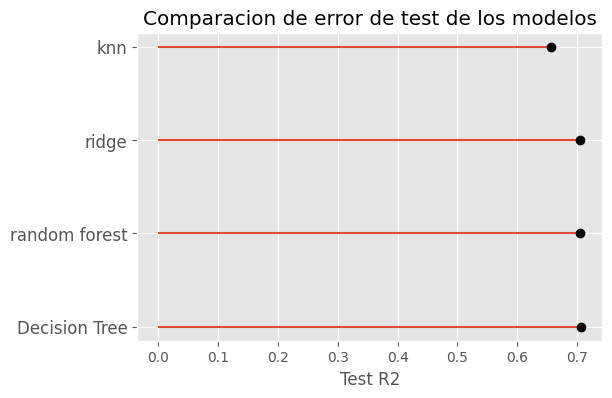

In [72]:
error_modelos = pd.DataFrame({
    'modelo':['knn','ridge','Decision Tree','random forest'],
    'r2': [r2_knn, r2_ridge, r2_decision,r2_rf]})

error_modelos = error_modelos.sort_values('r2', ascending = False)

fig, ax = plt.subplots(figsize = (6,4))

ax.hlines(error_modelos.modelo, xmin= 0, xmax = error_modelos.r2)
ax.plot(error_modelos.r2, error_modelos.modelo, 'o', color = 'black')
ax.tick_params(axis = 'y', which = 'major', labelsize = 12)
ax.set_title('Comparacion de error de test de los modelos')
ax.set_xlabel('Test R2')

En general, los modelos de Ridge, Random Forest y Decision Tree tiene una precisión similar cercana a 0,70. Se escoge el modelo de Decisión Tree

# Nuevos datos

In [76]:
datos_n = pd.read_csv('/content/insurance.csv')

datos_nuevos = datos_n[['age','sex','bmi','children','smoker','region']]

datos_nuevos

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [78]:
nuevas_predicciones = modelo_final_arbol.predict(datos_nuevos)
display(nuevas_predicciones)

array([ 9.76071229,  7.46030247,  8.53756973, ...,  7.77961468,
        7.77961468, 10.26447409])

In [79]:
datos_nuevos.insert(0,"Prediccion Precio", nuevas_predicciones, allow_duplicates="False")

datos_nuevos['Prediccion Precio'] = np.exp(datos_nuevos['Prediccion Precio'])

datos_nuevos.head(30)


,Prediccion Precio,age,sex,bmi,children,smoker,region
0,17338.977741,19,female,27.900,0,yes,southwest
1,1737.673575,18,male,33.770,1,no,southeast
2,5102.927810,28,male,33.000,3,no,southeast
3,5058.605850,33,male,22.705,0,no,northwest
4,3389.817384,32,male,28.880,0,no,northwest
5,3389.817384,31,female,25.740,0,no,southeast
6,8522.541413,46,female,33.440,1,no,southeast
7,7093.497418,37,female,27.740,3,no,northwest
8,7093.497418,37,male,29.830,2,no,northeast
9,14176.661485,60,female,25.840,0,no,northwest


In [ ]:
datos_n.head(30)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Si se compara las predicciones con los datos del dataset, se observa que en la mayoría de los casos se acercan a los reales. Para el fin del modelo, este sería útil para saber un apróximado de cuál sería el valor de la prima otorgado por la competencia en pólizas de vida que cuenten con esas variables y ofrecer un servicio más competitivo.